In [1]:
!nvidia-smi

Mon Mar 10 14:26:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%cd /kaggle/working/

/kaggle/working


In [3]:
!pip install bitsandbytes transformers accelerate peft -q

In [4]:
!pip install git+https://github.com/huggingface/diffusers.git -q

In [5]:
!pip install --upgrade diffusers

In [6]:
!pip install datasets -q

In [7]:
!pip install git+https://github.com/huggingface/peft.git

  Cloning https://github.com/huggingface/peft.git to /tmp/pip-req-build-ofg1andf
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft.git /tmp/pip-req-build-ofg1andf
  Resolved https://github.com/huggingface/peft.git to commit 8edaae9460e4b76bce9431dc187402178ff7b689
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peft: filename=peft-0.14.1.dev0-py3-none-any.whl size=410695 sha256=c25fccfee8cd53463f87fe1d7f1cfd0c960ba1042ea364f1a05e37d01eee351e
  Stored in directory: /tmp/pip-ephem-wheel-cache-dj95v65b/wheels/d7/c7/de/1368fac8590e1b103ddc2ec2a28ad51d83aded1a3830e8a087
Successfully built peft
  Attempting uninstall: peft
    Found existing installation: peft 0.14.0
    Uninstalling peft-0.14.0:
      Successfully uninstalled peft-0.14.0


In [8]:
!pip install wandb

In [9]:
# 045b86defe21c54f2a4a1a4d33b154a779baa21b

import os
import wandb

# Set the API key as an environment variable (recommended for security)
os.environ['WANDB_API_KEY'] = '045b86defe21c54f2a4a1a4d33b154a779baa21b'
# wandb.init()

In [10]:
import shutil

# Define source and destination paths
source_path = '/kaggle/input/sdxl-dataset/train_dreambooth_lora_sdxl.py'  # Replace with your source path
destination_path = '/kaggle/working/'  # Replace with your destination path

# Copy the file
shutil.copy(source_path, destination_path)


'/kaggle/working/train_dreambooth_lora_sdxl.py'

In [11]:
# Define source and destination paths
source_path = '/kaggle/input/sdxl-dataset/annotate_data.py'  # Replace with your source path
destination_path = '/kaggle/working/'  # Replace with your destination path

# Copy the file
shutil.copy(source_path, destination_path)

'/kaggle/working/annotate_data.py'

In [13]:
#!/usr/bin/env bash
!accelerate launch train_dreambooth_lora_sdxl.py \
--pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
--pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix" \
--dataset_name="/kaggle/input/backgrounds" \
--output_dir="backgrounds" \
--caption_column="prompt"\
--mixed_precision="fp16" \
--instance_prompt="background" \
--resolution=512 \
--train_batch_size=1 \
--gradient_accumulation_steps=1 \
--gradient_checkpointing \
--learning_rate=1e-4 \
--snr_gamma=1.5 \
--lr_scheduler="constant" \
--lr_warmup_steps=0 \
--mixed_precision="fp16" \
--use_8bit_adam \
--num_train_epochs=40 \
--checkpointing_steps=718 \
--seed="42" \
--rank=256 \
--report_to="wandb"

wandb imported
wandb imported
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: shujaan-azhar (raees-shujaan-azhar). Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: shujaan-azhar (raees-shujaan-azhar). Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.18.3
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250310_143255-r39n5kwv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dreambooth_lora_experiment
wandb: ⭐️ View project at https://wandb.ai/raees-shujaan-azhar/dreambooth-lora-sdxl_finetuning_project
wandb: 🚀 View run at https://wandb.ai/raees-shujaan-azhar/dreambooth-lora-sdxl_finetuning_project/runs/r39n5kwv
wandb: Tracking run with wandb version 0.18.3
wandb: Run data is saved locally in 

In [13]:
from PIL import Image
import os
import json
from datetime import datetime
import random

In [15]:
import torch
from diffusers import DiffusionPipeline, AutoencoderKL
from diffusers import StableDiffusionXLImg2ImgPipeline

vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)

pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True

)
pipe.load_lora_weights("/kaggle/working/cheezious", weight_name="pytorch_lora_weights.safetensors")
_ = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [16]:
# # Create a directory for saving images if it doesn't exist
# os.makedirs("Outputs", exist_ok=True)

# # Define the JSON file path for prompts
# prompt_json_path = "Outputs/prompt.json"

  0%|          | 0/50 [00:00<?, ?it/s]

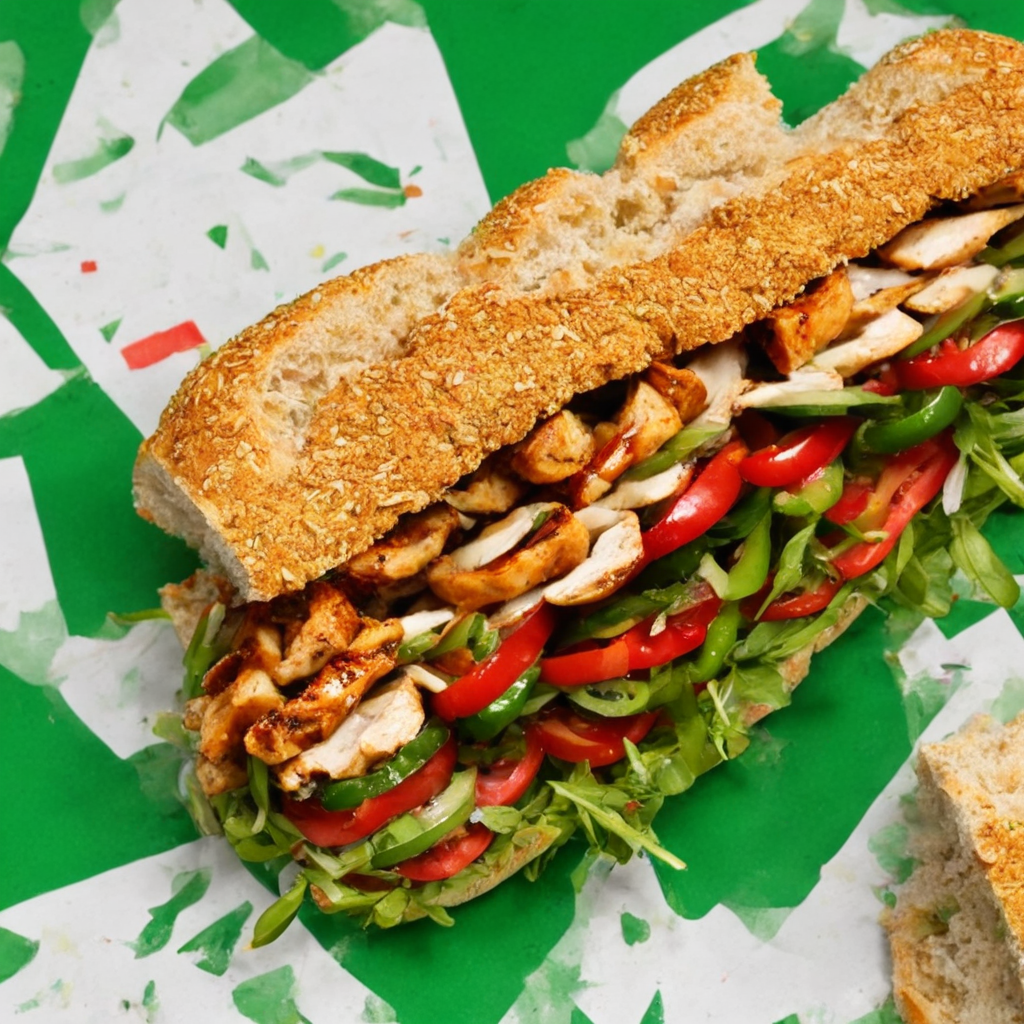

In [19]:
# # Generate a unique filename based on the current timestamp
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# image_name = f"generated_image_{timestamp}.png"
# image_path = os.path.join("Outputs", image_name)

input_prompt = "Generate A Subway sandwich featuring a toasted herb-crusted sub roll, filled with grilled chicken breast, fresh arugula, sliced mushrooms, green bell peppers, tomatoes, and onions, set against a modern white and green background."
# prefix_prompt = "A KFC pamphlet "

prompt = input_prompt
image = pipe(prompt=prompt, num_inference_steps=50).images[0]

# Save the image
# image.save(image_path)

# Prepare the prompt data to be saved
# prompt_data = {"image_name": image_name, "prompt": prompt}

# Append the prompt data to the JSON file
# if os.path.exists(prompt_json_path):
#     with open(prompt_json_path, "r") as f:
#         data = json.load(f)
# else:
#     data = []

# data.append(prompt_data)

# with open(prompt_json_path, "w") as f:
#     json.dump(data, f, indent=4)

# print(f"Image saved as {image_path} and prompt saved in {prompt_json_path}")

image

In [13]:
# Load the refiner pipeline
refiner_pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    torch_dtype=torch.float16, variant="fp16"
).to("cuda:1")

# refiner_pipe.load_lora_weights("/kaggle/working/cheezious", weight_name="pytorch_lora_weights.safetensors")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [14]:
# Then refine it for better detail
refined_image = refiner_pipe(
    prompt=input_prompt, 
    image=image, 
    strength=0.3,  # Adjust strength (0.3-0.8) for enhancement
    num_inference_steps=50
).images[0]
refined_image

  0%|          | 0/15 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 1 has a total capacity of 14.74 GiB of which 850.12 MiB is free. Process 3391 has 13.91 GiB memory in use. Of the allocated memory 13.34 GiB is allocated by PyTorch, and 445.57 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
image.save("deals.png")

In [12]:
import zipfile
import os

# Path to the directory you want to zip
dir_to_zip = '/kaggle/working/New_Weights'

# Specify the full path for the output zip file
zip_file = '/kaggle/working/New_Weights.zip'

# Create a zip file
with zipfile.ZipFile(zip_file, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder_name, subfolders, filenames in os.walk(dir_to_zip):
        for filename in filenames:
            file_path = os.path.join(folder_name, filename)
            arcname = os.path.relpath(file_path, dir_to_zip)  # Keep relative paths
            zipf.write(file_path, arcname=arcname)

print(f"Directory '{dir_to_zip}' has been zipped to '{zip_file}'")


OSError: [Errno 28] No space left on device